**05-Visualizations**  
Using outputs saved from 03 and 04, create visualizations that reveal patterns from the data. 

In [3]:
import os
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
REPO_ROOT = Path("~/scRNA-cross-donor-generalization").expanduser()   # change if needed
os.chdir(REPO_ROOT)

Scheme A columns: ['scheme', 'representation', 'macro_f1', 'accuracy', 'n_cells_used', 'n_classes_used', 'dataset', 'batch', 'batch_covariate', 'n_batch_features']
Scheme B columns: ['scheme', 'dataset', 'batch', 'representation', 'macro_f1_mean', 'macro_f1_std', 'accuracy_mean', 'accuracy_std', 'n_folds', 'mean_train_cells', 'mean_test_cells', 'mean_n_classes_used', 'batch_covariate', 'mean_n_batch_features']


,scheme,representation,macro_f1,accuracy,n_cells_used,n_classes_used,dataset,batch,batch_covariate,n_batch_features
0,random,pca,0.789837,0.822948,10107,13,filtered,no,NaN,NaN
1,random,hvg,0.789520,0.817013,10107,13,filtered,no,NaN,NaN
2,random,scvi,0.757488,0.791790,10107,13,filtered,no,NaN,NaN
3,random,harmony,0.755549,0.789812,10107,13,filtered,no,NaN,NaN
4,random_batchcov,pca,0.794516,0.825420,10107,13,filtered,yes,Site,2.0
5,random_batchcov,hvg,0.790476,0.818497,10107,13,filtered,yes,Site,2.0
6,random_batchcov,harmony,0.765867,0.801682,10107,13,filtered,yes,Site,2.0
7,random_batchcov,scvi,0.765186,0.799209,10107,13,filtered,yes,Site,2.0
8,random,hvg,0.508945,0.766608,11289,40,full,no,NaN,NaN
9,random,scvi,0.508365,0.759522,11289,40,full,no,NaN,NaN


,scheme,dataset,batch,representation,macro_f1_mean,macro_f1_std,accuracy_mean,accuracy_std,n_folds,mean_train_cells,mean_test_cells,mean_n_classes_used,batch_covariate,mean_n_batch_features
0,donor_held_out,filtered,no,X_pca,0.775636,0.031406,0.813954,0.037290,5,8085.6,2021.4,13.0,NaN,0.0
1,donor_held_out,filtered,no,hvg,0.765229,0.019433,0.802494,0.023497,5,8085.6,2021.4,13.0,NaN,0.0
2,donor_held_out,filtered,no,X_harmony,0.748225,0.030225,0.788531,0.035855,5,8085.6,2021.4,13.0,NaN,0.0
3,donor_held_out,filtered,no,X_scVI,0.744218,0.034787,0.787228,0.040640,5,8085.6,2021.4,13.0,NaN,0.0
4,donor_held_out_batchcov,filtered,yes,X_pca,0.776870,0.033406,0.814029,0.037734,5,8085.6,2021.4,13.0,Site,2.0
5,donor_held_out_batchcov,filtered,yes,hvg,0.764340,0.020338,0.801585,0.024353,5,8085.6,2021.4,13.0,Site,2.0
6,donor_held_out_batchcov,filtered,yes,X_harmony,0.747530,0.042606,0.791621,0.041989,5,8085.6,2021.4,13.0,Site,2.0
7,donor_held_out_batchcov,filtered,yes,X_scVI,0.743975,0.038099,0.790279,0.038479,5,8085.6,2021.4,13.0,Site,2.0


Plotting dataframe:


,representation,macro_f1,accuracy,macro_f1_std,scheme_label
0,hvg,0.765229,0.802494,0.019433,Donor-held-out
1,hvg,0.789520,0.817013,0.000000,Random split
2,pca,0.775636,0.813954,0.031406,Donor-held-out
3,pca,0.789837,0.822948,0.000000,Random split
4,harmony,0.748225,0.788531,0.030225,Donor-held-out
5,harmony,0.755549,0.789812,0.000000,Random split
6,scvi,0.744218,0.787228,0.034787,Donor-held-out
7,scvi,0.757488,0.791790,0.000000,Random split


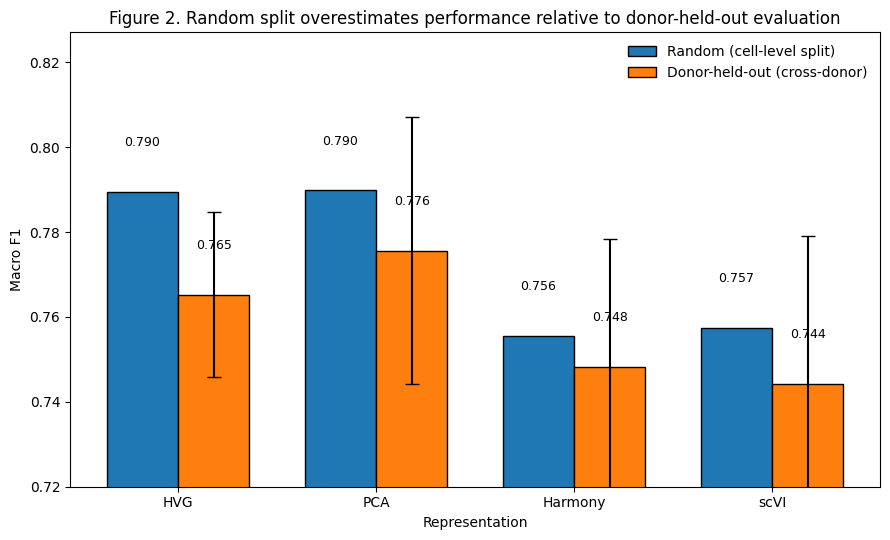

Saved: results/figures/figure2_random_vs_donorheldout_macroF1.png


In [11]:
# -------------------------
# paths
# -------------------------
tables_dir = Path("results/tables")
figures_dir = Path("results/figures")
figures_dir.mkdir(parents=True, exist_ok=True)

schemeA_path = tables_dir / "schemeA_summary.csv"
schemeB_path = tables_dir / "schemeB_summary.csv"

# -------------------------
# read csvs
# -------------------------
schemeA = pd.read_csv(schemeA_path)
schemeB = pd.read_csv(schemeB_path)

print("Scheme A columns:", schemeA.columns.tolist())
print("Scheme B columns:", schemeB.columns.tolist())

display(schemeA)
display(schemeB)

# -------------------------
# Figure 2 = main comparison
# filtered dataset, no batch covariate
# Scheme A: random split
# Scheme B: donor-held-out
# -------------------------
fig2_A = schemeA[
    (schemeA["dataset"] == "filtered") &
    (schemeA["batch"] == "no")
].copy()

fig2_B = schemeB[
    (schemeB["dataset"] == "filtered") &
    (schemeB["batch"] == "no")
].copy()

# keep only needed columns and standardize names
fig2_A = fig2_A[["representation", "macro_f1", "accuracy"]].copy()
fig2_A["macro_f1_std"] = 0.0
fig2_A["scheme_label"] = "Random split"

fig2_B = fig2_B[["representation", "macro_f1_mean", "macro_f1_std", "accuracy_mean"]].copy()
fig2_B["representation"] = fig2_B["representation"].replace({
    "X_pca": "pca",
    "X_harmony": "harmony",
    "X_scVI": "scvi",
})
fig2_B = fig2_B.rename(columns={
    "macro_f1_mean": "macro_f1",
    "accuracy_mean": "accuracy"
})
fig2_B["scheme_label"] = "Donor-held-out"

plot_df = pd.concat([fig2_A, fig2_B], ignore_index=True)

# representation order in your notebooks
rep_order = ["hvg", "pca", "harmony", "scvi"]
plot_df["representation"] = pd.Categorical(
    plot_df["representation"],
    categories=rep_order,
    ordered=True
)
plot_df = plot_df.sort_values(["representation", "scheme_label"]).reset_index(drop=True)

print("Plotting dataframe:")
display(plot_df)

# -------------------------
# split by scheme
# -------------------------
random_df = (
    plot_df[plot_df["scheme_label"] == "Random split"]
    .set_index("representation")
    .loc[rep_order]
)

donor_df = (
    plot_df[plot_df["scheme_label"] == "Donor-held-out"]
    .set_index("representation")
    .loc[rep_order]
)

# -------------------------
# plot
# -------------------------
x = np.arange(len(rep_order))
width = 0.36

fig, ax = plt.subplots(figsize=(9, 5.5))

bars_random = ax.bar(
    x - width/2,
    random_df["macro_f1"],
    width,
    label="Random (cell-level split)",
    edgecolor="black"
)

bars_donor = ax.bar(
    x + width/2,
    donor_df["macro_f1"],
    width,
    yerr=donor_df["macro_f1_std"],
    capsize=5,
    label="Donor-held-out (cross-donor)",
    edgecolor="black"
)

ax.set_xticks(x)
ax.set_xticklabels(["HVG", "PCA", "Harmony", "scVI"])
ax.set_xlabel("Representation")
ax.set_ylabel("Macro F1")
ax.set_title("Figure 2. Random split overestimates performance relative to donor-held-out evaluation")
ax.legend(frameon=False)

ymax = max(
    random_df["macro_f1"].max(),
    (donor_df["macro_f1"] + donor_df["macro_f1_std"]).max()
)
ax.set_ylim(0.72, ymax + 0.02)

# add value labels
for bars in [bars_random, bars_donor]:
    for bar in bars:
        h = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width()/2,
            h + 0.01,
            f"{h:.3f}",
            ha="center",
            va="bottom",
            fontsize=9
        )

plt.tight_layout()

out_png = figures_dir / "figure2_random_vs_donorheldout_macroF1.png"

plt.savefig(out_png, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved: {out_png}")

Panel A:


,scheme,dataset,batch,representation,macro_f1_mean,macro_f1_std,accuracy_mean,accuracy_std,n_folds,mean_train_cells,mean_test_cells,mean_n_classes_used,batch_covariate,mean_n_batch_features
representation_clean,,,,,,,,,,,,,,
hvg,donor_held_out,filtered,no,hvg,0.765229,0.019433,0.802494,0.023497,5,8085.6,2021.4,13.0,NaN,0.0
pca,donor_held_out,filtered,no,X_pca,0.775636,0.031406,0.813954,0.037290,5,8085.6,2021.4,13.0,NaN,0.0
harmony,donor_held_out,filtered,no,X_harmony,0.748225,0.030225,0.788531,0.035855,5,8085.6,2021.4,13.0,NaN,0.0
scvi,donor_held_out,filtered,no,X_scVI,0.744218,0.034787,0.787228,0.040640,5,8085.6,2021.4,13.0,NaN,0.0


Panel B:


,scheme,dataset,batch,representation,macro_f1_mean,macro_f1_std,accuracy_mean,accuracy_std,n_folds,mean_train_cells,mean_test_cells,mean_n_classes_used,batch_covariate,mean_n_batch_features
representation_clean,,,,,,,,,,,,,,
hvg,donor_held_out_batchcov,filtered,yes,hvg,0.764340,0.020338,0.801585,0.024353,5,8085.6,2021.4,13.0,Site,2.0
pca,donor_held_out_batchcov,filtered,yes,X_pca,0.776870,0.033406,0.814029,0.037734,5,8085.6,2021.4,13.0,Site,2.0
harmony,donor_held_out_batchcov,filtered,yes,X_harmony,0.747530,0.042606,0.791621,0.041989,5,8085.6,2021.4,13.0,Site,2.0
scvi,donor_held_out_batchcov,filtered,yes,X_scVI,0.743975,0.038099,0.790279,0.038479,5,8085.6,2021.4,13.0,Site,2.0


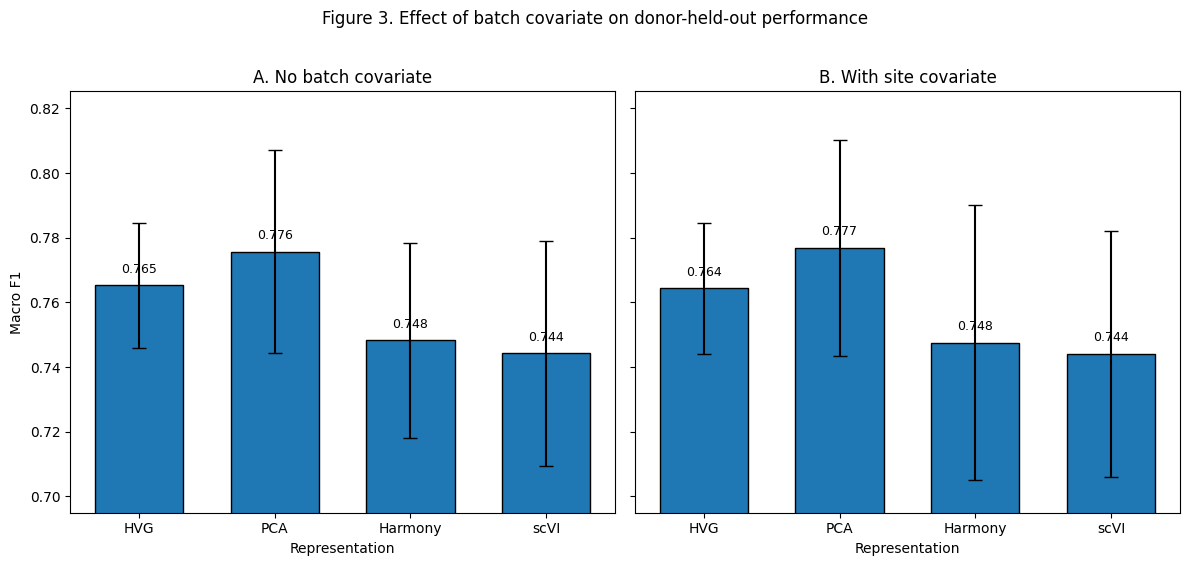

Saved: results/figures/figure3_schemeB_batch_comparison.png


In [12]:
# figure 3: batch covariate comparison in Scheme B

# -------------------------
# keep filtered dataset only
# -------------------------
fig3_df = schemeB[schemeB["dataset"] == "filtered"].copy()

# harmonize representation names
fig3_df["representation_clean"] = fig3_df["representation"].replace({
    "hvg": "hvg",
    "X_pca": "pca",
    "X_harmony": "harmony",
    "X_scVI": "scvi",
})

rep_order = ["hvg", "pca", "harmony", "scvi"]
rep_labels = ["HVG", "PCA", "Harmony", "scVI"]

# split into no-batch and batch panels
panel_A = (
    fig3_df[fig3_df["batch"] == "no"]
    .set_index("representation_clean")
    .reindex(rep_order)
)

panel_B = (
    fig3_df[fig3_df["batch"] == "yes"]
    .set_index("representation_clean")
    .reindex(rep_order)
)

print("Panel A:")
display(panel_A)

print("Panel B:")
display(panel_B)

# -------------------------
# plot
# -------------------------
x = np.arange(len(rep_order))
width = 0.65

fig, axes = plt.subplots(1, 2, figsize=(12, 5.5), sharey=True)

# common y-limits
ymin = min(
    (panel_A["macro_f1_mean"] - panel_A["macro_f1_std"]).min(),
    (panel_B["macro_f1_mean"] - panel_B["macro_f1_std"]).min(),
)
ymax = max(
    (panel_A["macro_f1_mean"] + panel_A["macro_f1_std"]).max(),
    (panel_B["macro_f1_mean"] + panel_B["macro_f1_std"]).max(),
)

# -------- Panel A --------
bars_A = axes[0].bar(
    x,
    panel_A["macro_f1_mean"],
    width,
    yerr=panel_A["macro_f1_std"],
    capsize=5,
    edgecolor="black"
)
axes[0].set_xticks(x)
axes[0].set_xticklabels(rep_labels)
axes[0].set_xlabel("Representation")
axes[0].set_ylabel("Macro F1")
axes[0].set_title("A. No batch covariate")

for bar in bars_A:
    h = bar.get_height()
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        h + 0.003,
        f"{h:.3f}",
        ha="center",
        va="bottom",
        fontsize=9
    )

# -------- Panel B --------
bars_B = axes[1].bar(
    x,
    panel_B["macro_f1_mean"],
    width,
    yerr=panel_B["macro_f1_std"],
    capsize=5,
    edgecolor="black"
)
axes[1].set_xticks(x)
axes[1].set_xticklabels(rep_labels)
axes[1].set_xlabel("Representation")
axes[1].set_title("B. With site covariate")

for bar in bars_B:
    h = bar.get_height()
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        h + 0.003,
        f"{h:.3f}",
        ha="center",
        va="bottom",
        fontsize=9
    )

for ax in axes:
    ax.set_ylim(ymin - 0.01, ymax + 0.015)

fig.suptitle("Figure 3. Effect of batch covariate on donor-held-out performance", y=1.02)
plt.tight_layout()

out_png = figures_dir / "figure3_schemeB_batch_comparison.png"
plt.savefig(out_png, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved: {out_png}")

Figure 4 heatmap table:


,cell_type,HVG,PCA,Harmony,scVI,mean_f1
0,naive B cell,0.995878,1.000000,1.000000,1.000000,0.998969
1,CD14-positive monocyte,0.993192,0.992658,0.990366,0.991450,0.991917
2,"CD16-positive, CD56-dim natural killer cell, h...",0.953467,0.951901,0.929354,0.942747,0.944367
3,"CD16-negative, CD56-bright natural killer cell...",0.897794,0.859457,0.853364,0.866178,0.869198
4,mature NK T cell,0.870048,0.868419,0.867072,0.858740,0.866070
5,"naive thymus-derived CD4-positive, alpha-beta ...",0.810045,0.846472,0.820351,0.811713,0.822145
6,"effector CD8-positive, alpha-beta T cell",0.789202,0.809478,0.744862,0.763876,0.776854
7,"naive thymus-derived CD8-positive, alpha-beta ...",0.771441,0.680202,0.661297,0.675022,0.696991
8,"effector memory CD8-positive, alpha-beta T cell",0.676920,0.717628,0.685100,0.655708,0.683839
9,"central memory CD4-positive, alpha-beta T cell",0.625485,0.658088,0.609165,0.624611,0.629337


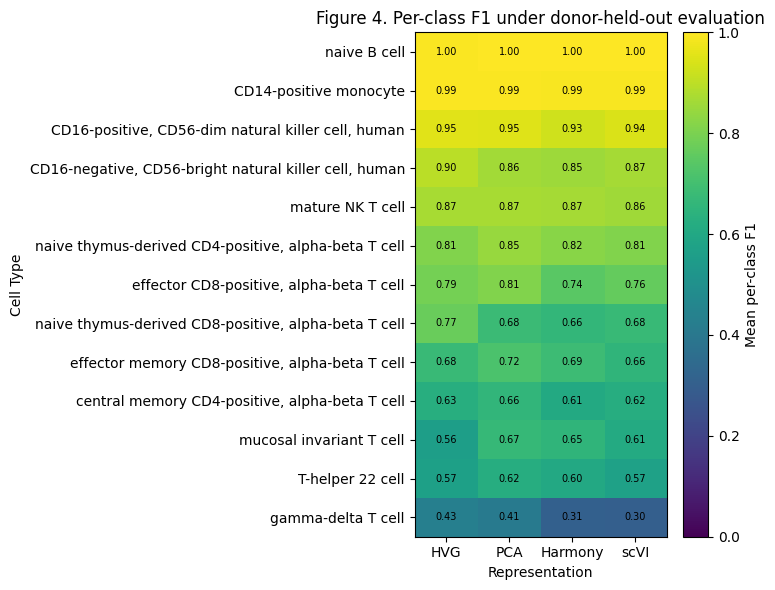

Saved: results/figures/figure4_schemeB_per_class_f1_heatmap.png


In [14]:
# figure 4: per-class F1 heatmap for Scheme B (filtered, no batch)

# -------------------------
# paths
# -------------------------
schemeB_case1_dir = Path("results/schemeB_case1")
figures_dir = Path("results/figures")
figures_dir.mkdir(parents=True, exist_ok=True)

# file names from notebook outputs
rep_file_map = {
    "HVG": "schemeB_case1_hvg_mean_per_class_f1.csv",
    "PCA": "schemeB_case1_X_pca_mean_per_class_f1.csv",
    "Harmony": "schemeB_case1_X_harmony_mean_per_class_f1.csv",
    "scVI": "schemeB_case1_X_scVI_mean_per_class_f1.csv",
}

# -------------------------
# read and merge
# -------------------------
heatmap_parts = []

for rep_label, fname in rep_file_map.items():
    df = pd.read_csv(schemeB_case1_dir / fname)
    df = df[["cell_type", "f1"]].copy()
    df = df.rename(columns={"f1": rep_label})
    heatmap_parts.append(df)

heatmap_df = heatmap_parts[0]
for df in heatmap_parts[1:]:
    heatmap_df = heatmap_df.merge(df, on="cell_type", how="outer")

# sort cell types by mean F1 across representations
rep_cols = ["HVG", "PCA", "Harmony", "scVI"]
heatmap_df["mean_f1"] = heatmap_df[rep_cols].mean(axis=1)
heatmap_df = heatmap_df.sort_values("mean_f1", ascending=False).reset_index(drop=True)

# use cell_type as index for plotting
heatmap_plot = heatmap_df.set_index("cell_type")[rep_cols]

print("Figure 4 heatmap table:")
display(heatmap_df)

# -------------------------
# plot heatmap
# -------------------------
fig_height = max(6, 0.45 * heatmap_plot.shape[0])
fig, ax = plt.subplots(figsize=(7.5, fig_height))

im = ax.imshow(
    heatmap_plot.values,
    aspect="auto",
    vmin=0,
    vmax=1,
)

# axes
ax.set_xticks(np.arange(len(rep_cols)))
ax.set_xticklabels(rep_cols)
ax.set_yticks(np.arange(len(heatmap_plot.index)))
ax.set_yticklabels(heatmap_plot.index)

ax.set_xlabel("Representation")
ax.set_ylabel("Cell Type")
ax.set_title("Figure 4. Per-class F1 under donor-held-out evaluation")

# colorbar
cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Mean per-class F1")

# optional in-cell text
for i in range(heatmap_plot.shape[0]):
    for j in range(heatmap_plot.shape[1]):
        val = heatmap_plot.iloc[i, j]
        ax.text(
            j,
            i,
            f"{val:.2f}",
            ha="center",
            va="center",
            fontsize=7,
            color="black"
        )

plt.tight_layout()

out_png = figures_dir / "figure4_schemeB_per_class_f1_heatmap.png"
plt.savefig(out_png, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved: {out_png}")

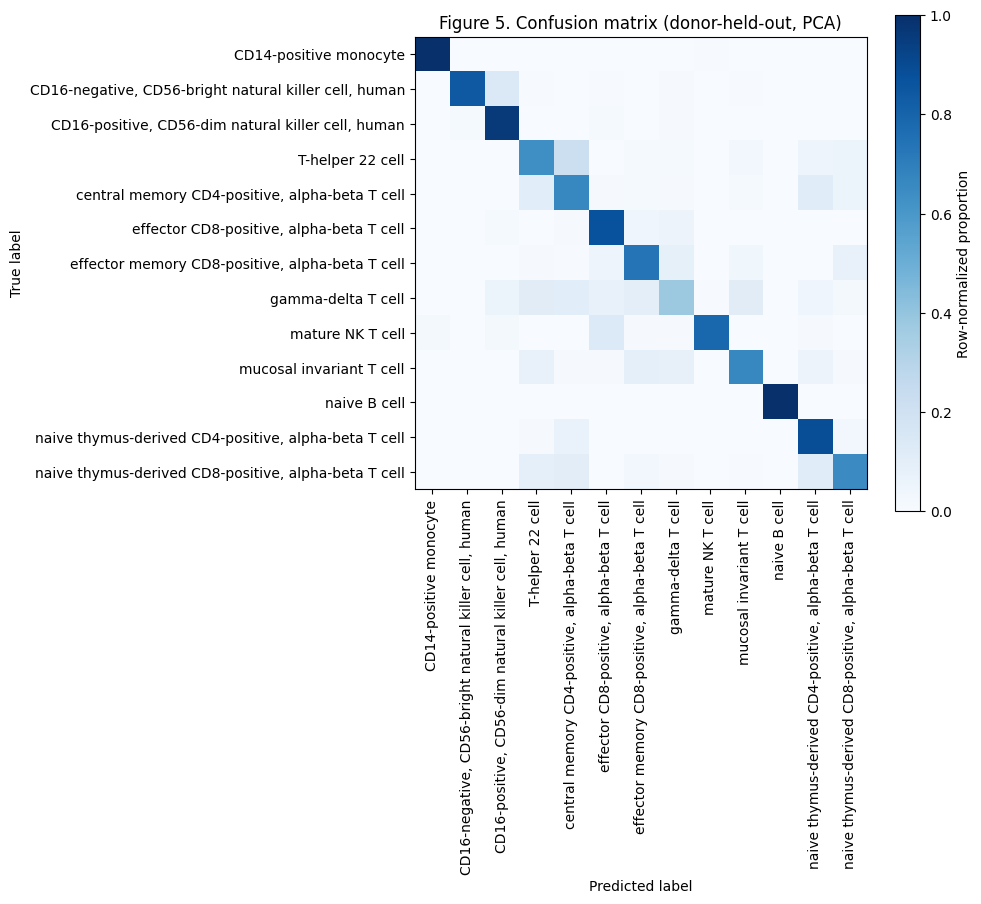

Saved: results/figures/figure5_confusion_matrix_pca.png


In [15]:
# figure 5: confusion matrix (Scheme B, PCA, filtered dataset)

# -------------------------
# path
# -------------------------
cm_path = Path("results/schemeB_case1/schemeB_case1_X_pca_confusion_matrix_sum.csv")
figures_dir = Path("results/figures")
figures_dir.mkdir(parents=True, exist_ok=True)

# -------------------------
# load matrix
# -------------------------
cm_df = pd.read_csv(cm_path, index_col=0)

# normalize rows
cm = cm_df.values
row_sums = cm.sum(axis=1, keepdims=True)
cm_norm = np.divide(cm, row_sums, where=row_sums != 0)

# -------------------------
# plot
# -------------------------
fig, ax = plt.subplots(figsize=(10, 9))

im = ax.imshow(cm_norm, cmap="Blues", vmin=0, vmax=1)

# ticks
labels = cm_df.index.tolist()
ax.set_xticks(np.arange(len(labels)))
ax.set_yticks(np.arange(len(labels)))

ax.set_xticklabels(labels, rotation=90)
ax.set_yticklabels(labels)

ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")
ax.set_title("Figure 5. Confusion matrix (donor-held-out, PCA)")

# colorbar
cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Row-normalized proportion")

plt.tight_layout()

out_png = figures_dir / "figure5_confusion_matrix_pca.png"
plt.savefig(out_png, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved: {out_png}")

Ablation columns: ['representation', 'k_train_donors', 'macro_f1_mean', 'macro_f1_std', 'accuracy_mean', 'accuracy_std', 'mean_train_cells', 'mean_test_cells', 'mean_n_classes_used']


,representation,k_train_donors,macro_f1_mean,macro_f1_std,accuracy_mean,accuracy_std,mean_train_cells,mean_test_cells,mean_n_classes_used
0,harmony,3,0.485158,0.034869,0.679678,0.042265,1466.6,9707.2,29.4
1,harmony,5,0.469859,0.019344,0.722554,0.015562,2427.4,8777.6,33.2
2,harmony,8,0.464182,0.013109,0.736144,0.015007,3930.2,7338.0,36.4
3,harmony,10,0.461591,0.013484,0.752793,0.011257,4926.0,6347.0,37.4
4,harmony,15,0.481000,0.019062,0.756894,0.016221,7366.6,3919.6,39.2
5,harmony,20,0.486289,0.046632,0.734730,0.042272,9808.6,1480.4,40.0
6,hvg,3,0.513929,0.060348,0.666976,0.061552,1466.6,9707.2,29.4
7,hvg,5,0.527462,0.024506,0.721837,0.021116,2427.4,8777.6,33.2
8,hvg,8,0.508345,0.006211,0.745630,0.019366,3930.2,7338.0,36.4
9,hvg,10,0.509563,0.015852,0.763401,0.015286,4926.0,6347.0,37.4


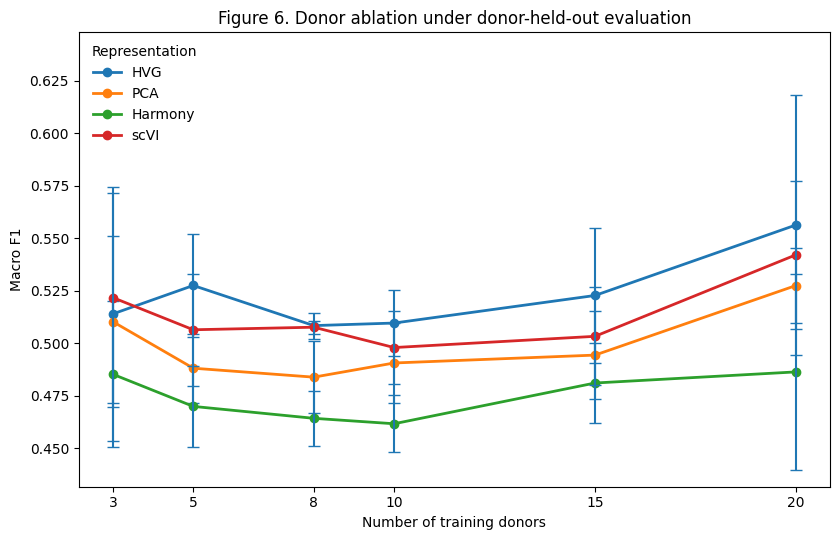

Saved: results/figures/figure6_donor_ablation.png


In [16]:
# figure 6: donor ablation curve

# -------------------------
# path
# -------------------------
ablation_path = Path("results/tables/donor_ablation_summary.csv")
figures_dir = Path("results/figures")
figures_dir.mkdir(parents=True, exist_ok=True)

# -------------------------
# read csv
# -------------------------
ablation_df = pd.read_csv(ablation_path)

print("Ablation columns:", ablation_df.columns.tolist())
display(ablation_df)

# harmonize representation names if needed
ablation_df["representation_clean"] = ablation_df["representation"].replace({
    "hvg": "HVG",
    "pca": "PCA",
    "harmony": "Harmony",
    "scvi": "scVI",
    "X_pca": "PCA",
    "X_harmony": "Harmony",
    "X_scVI": "scVI",
})

rep_order = ["HVG", "PCA", "Harmony", "scVI"]

# -------------------------
# plot
# -------------------------
fig, ax = plt.subplots(figsize=(8.5, 5.5))

for rep in rep_order:
    sub = (
        ablation_df[ablation_df["representation_clean"] == rep]
        .sort_values("k_train_donors")
        .copy()
    )

    ax.plot(
        sub["k_train_donors"],
        sub["macro_f1_mean"],
        marker="o",
        linewidth=2,
        label=rep
    )

    ax.errorbar(
        sub["k_train_donors"],
        sub["macro_f1_mean"],
        yerr=sub["macro_f1_std"],
        fmt="none",
        capsize=4
    )

ax.set_xlabel("Number of training donors")
ax.set_ylabel("Macro F1")
ax.set_title("Figure 6. Donor ablation under donor-held-out evaluation")
ax.legend(frameon=False, title="Representation")

ax.set_xticks(sorted(ablation_df["k_train_donors"].unique()))
ax.set_ylim(
    ablation_df["macro_f1_mean"].min() - 0.03,
    (ablation_df["macro_f1_mean"] + ablation_df["macro_f1_std"]).max() + 0.03
)

plt.tight_layout()

out_png = figures_dir / "figure6_donor_ablation.png"
plt.savefig(out_png, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved: {out_png}")

**Supplementary Figures**

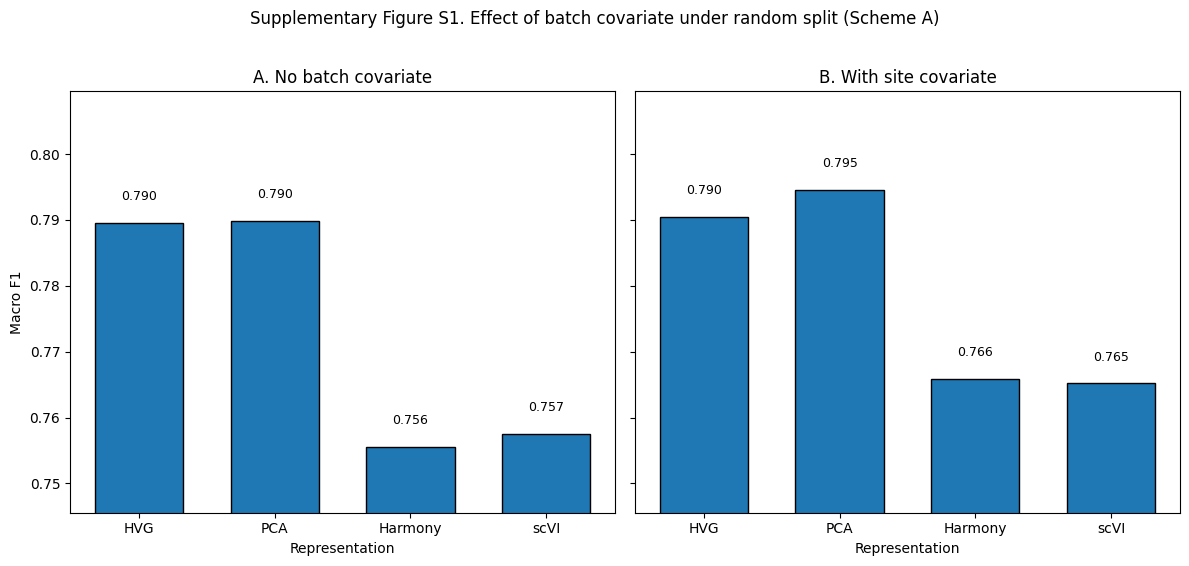

Saved: results/figures/supplementary_S1_schemeA_batch.png


In [17]:
# =========================
# SUPPLEMENTARY FIGURE S1
# Scheme A: Random split
# Effect of batch covariate
# =========================

figS1_df = schemeA.copy()

# restrict to filtered dataset
figS1_df = figS1_df[figS1_df["dataset"] == "filtered"].copy()

# clean representation names
figS1_df["representation_clean"] = figS1_df["representation"].replace({
    "hvg": "hvg",
    "X_pca": "pca",
    "X_harmony": "harmony",
    "X_scVI": "scvi",
})

rep_order = ["hvg", "pca", "harmony", "scvi"]
rep_labels = ["HVG", "PCA", "Harmony", "scVI"]

# split panels
panel_A = (
    figS1_df[figS1_df["batch"] == "no"]
    .set_index("representation_clean")
    .reindex(rep_order)
)

panel_B = (
    figS1_df[figS1_df["batch"] == "yes"]
    .set_index("representation_clean")
    .reindex(rep_order)
)

# -------------------------
# plot
# -------------------------
x = np.arange(len(rep_order))
width = 0.65

fig, axes = plt.subplots(1, 2, figsize=(12, 5.5), sharey=True)

# -------- Panel A --------
bars_A = axes[0].bar(
    x,
    panel_A["macro_f1"],
    width,
    edgecolor="black"
)

axes[0].set_xticks(x)
axes[0].set_xticklabels(rep_labels)
axes[0].set_xlabel("Representation")
axes[0].set_ylabel("Macro F1")
axes[0].set_title("A. No batch covariate")

# labels
for bar in bars_A:
    h = bar.get_height()
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        h + 0.003,
        f"{h:.3f}",
        ha="center",
        va="bottom",
        fontsize=9
    )

# -------- Panel B --------
bars_B = axes[1].bar(
    x,
    panel_B["macro_f1"],
    width,
    edgecolor="black"
)

axes[1].set_xticks(x)
axes[1].set_xticklabels(rep_labels)
axes[1].set_xlabel("Representation")
axes[1].set_title("B. With site covariate")

for bar in bars_B:
    h = bar.get_height()
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        h + 0.003,
        f"{h:.3f}",
        ha="center",
        va="bottom",
        fontsize=9
    )

# shared y-axis
ymin = min(panel_A["macro_f1"].min(), panel_B["macro_f1"].min())
ymax = max(panel_A["macro_f1"].max(), panel_B["macro_f1"].max())

for ax in axes:
    ax.set_ylim(ymin - 0.01, ymax + 0.015)

fig.suptitle(
    "Supplementary Figure S1. Effect of batch covariate under random split (Scheme A)",
    y=1.02
)

plt.tight_layout()

out_png = figures_dir / "supplementary_S1_schemeA_batch.png"
plt.savefig(out_png, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved: {out_png}")

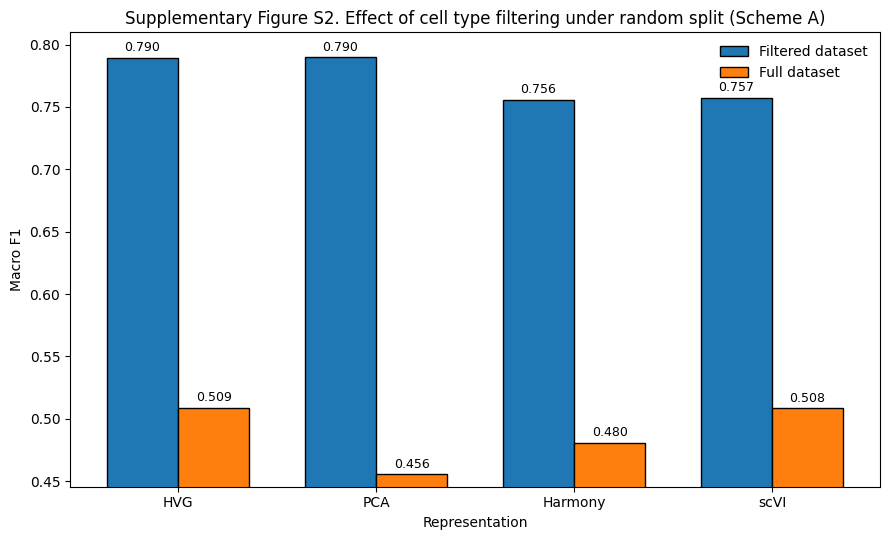

Saved: results/figures/supplementary_S2_schemeA_filtered_vs_full_grouped.png


In [19]:
# =========================
# SUPPLEMENTARY FIGURE S2
# Scheme A: filtered vs full
# no batch covariate
# grouped bar chart
# =========================

figS2_df = schemeA[schemeA["batch"] == "no"].copy()

# clean representation names if needed
figS2_df["representation_clean"] = figS2_df["representation"].replace({
    "hvg": "hvg",
    "X_pca": "pca",
    "X_harmony": "harmony",
    "X_scVI": "scvi",
})

rep_order = ["hvg", "pca", "harmony", "scvi"]
rep_labels = ["HVG", "PCA", "Harmony", "scVI"]

filtered_df = (
    figS2_df[figS2_df["dataset"] == "filtered"]
    .set_index("representation_clean")
    .reindex(rep_order)
)

full_df = (
    figS2_df[figS2_df["dataset"] == "full"]
    .set_index("representation_clean")
    .reindex(rep_order)
)

x = np.arange(len(rep_order))
width = 0.36

fig, ax = plt.subplots(figsize=(9, 5.5))

bars_filtered = ax.bar(
    x - width/2,
    filtered_df["macro_f1"],
    width,
    label="Filtered dataset",
    edgecolor="black"
)

bars_full = ax.bar(
    x + width/2,
    full_df["macro_f1"],
    width,
    label="Full dataset",
    edgecolor="black"
)

ax.set_xticks(x)
ax.set_xticklabels(rep_labels)
ax.set_xlabel("Representation")
ax.set_ylabel("Macro F1")
ax.set_title("Supplementary Figure S2. Effect of cell type filtering under random split (Scheme A)")
ax.legend(frameon=False)

ymin = min(filtered_df["macro_f1"].min(), full_df["macro_f1"].min())
ymax = max(filtered_df["macro_f1"].max(), full_df["macro_f1"].max())
ax.set_ylim(ymin - 0.01, ymax + 0.02)

for bars in [bars_filtered, bars_full]:
    for bar in bars:
        h = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            h + 0.003,
            f"{h:.3f}",
            ha="center",
            va="bottom",
            fontsize=9
        )

plt.tight_layout()

out_png = figures_dir / "supplementary_S2_schemeA_filtered_vs_full_grouped.png"
plt.savefig(out_png, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved: {out_png}")